## Exploratory Data Analysis

### Packages

In [3]:
# Data handling
import pandas as pd
import geopandas as gpd

#required import for geopandas (as we are using it), that was not auto installed as a dependency
import pyarrow

# Data reading
import requests
from io import BytesIO, StringIO

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import leafmap.foliumap as leafmap

# numpy
import numpy as np


### Read the Clean Datasets

In [4]:
# Read the OD flows parquet file into a GeoDataFrame
url_flows = "https://raw.githubusercontent.com/iansargent/nyc-subway-ridership-ml/main/Data/Clean/origin_destination_flows_CLEAN.parquet"
r_flows = requests.get(url_flows)
od_flows = gpd.read_parquet(BytesIO(r_flows.content))

# Read the origin time series file into a DataFrame
url_ts = "https://raw.githubusercontent.com/iansargent/nyc-subway-ridership-ml/main/Data/Clean/origin_ridership_time_series_CLEAN.csv"
origin = pd.read_csv(StringIO(requests.get(url_ts, verify=False).text))

### Displaying the Clean Datasets

In [5]:
display(od_flows.head())
display(origin.head())

,origin_station_complex_name,destination_station_complex_name,origin_station_complex_id,destination_station_complex_id,sum_estimated_average_ridership,geometry,distance_meters,distance_km,log_ridership,riders_per_km,origin_point_wkt,destination_point_wkt
0,Beach 44 St (A),Grand St (L),206,123,30.2032,"LINESTRING (-73.77601 40.59294, -73.94067 40.7...",19191.098843,19.191099,3.440521,1.573813,POINT (-73.776013 40.592943),POINT (-73.94067 40.711926)
1,57 St (F),"Astoria Blvd (N,W)",224,2,595.8536,"LINESTRING (-73.97745 40.76397, -73.91784 40.7...",5079.298729,5.079299,6.391672,117.310210,POINT (-73.97745 40.763972),POINT (-73.917843 40.770258)
2,Rector St (1),Buhre Av (6),329,361,8.8919,"LINESTRING (-74.01378 40.70751, -73.83257 40.8...",21749.099473,21.749099,2.291716,0.408840,POINT (-74.013783 40.707513),POINT (-73.832569 40.84681)
3,"30 Av (N,W)","Simpson St (2,5)",3,430,222.4353,"LINESTRING (-73.92148 40.76678, -73.89306 40.8...",6797.412960,6.797413,5.409122,32.723523,POINT (-73.921479 40.766779),POINT (-73.893064 40.824073)
4,"Northern Blvd (M,R)",2 Av (F),269,232,1036.2171,"LINESTRING (-73.90601 40.75288, -73.98994 40.7...",7806.638810,7.806639,6.944297,132.735371,POINT (-73.906006 40.752885),POINT (-73.989938 40.723402)


,month,day_of_week,hour_of_day,origin_station_complex_id,origin_station_complex_name,origin_latitude,origin_longitude,origin_point,sum_estimated_average_ridership
0,1,Friday,0,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),35.7473
1,1,Friday,1,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),11.4975
2,1,Friday,2,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),10.9980
3,1,Friday,3,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),14.7534
4,1,Friday,4,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),52.0023


## Descriptive Statistics

In [4]:
origin[origin['day_of_week'] == 'Friday']['sum_estimated_average_ridership'].sum()

np.float64(42555436.7229)

## Distributions

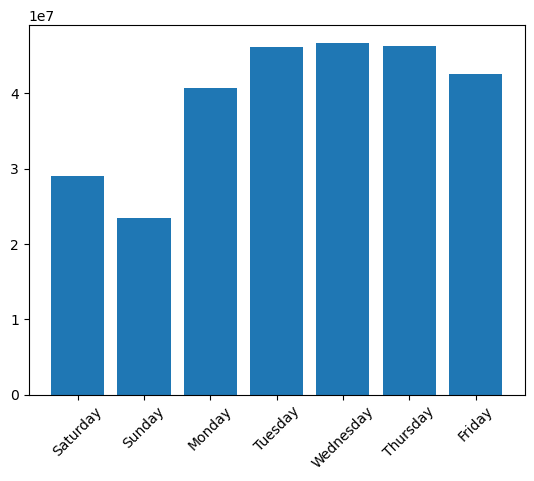

Day of the week: total ridership
Saturday: 29009734.824400004
Sunday: 23397423.0419
Monday: 40750677.3636
Tuesday: 46106946.1171
Wednesday: 46749949.310100004
Thursday: 46325195.726799995
Friday: 42555436.7229


In [5]:
# origin day of week
day_of_week = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
total_ridership_per_day_of_week = [origin[origin['day_of_week'] == i]['sum_estimated_average_ridership'].sum() for i in day_of_week]
plt.bar(day_of_week, total_ridership_per_day_of_week)
plt.tick_params(axis='x', labelrotation=45)
# plt.ticklabel_format(style='plain') #for some reason this is only causing an error for this graph
plt.show()
print('Day of the week: total ridership')
for i in range(7):
    print(f'{day_of_week[i]}: {total_ridership_per_day_of_week[i]}')

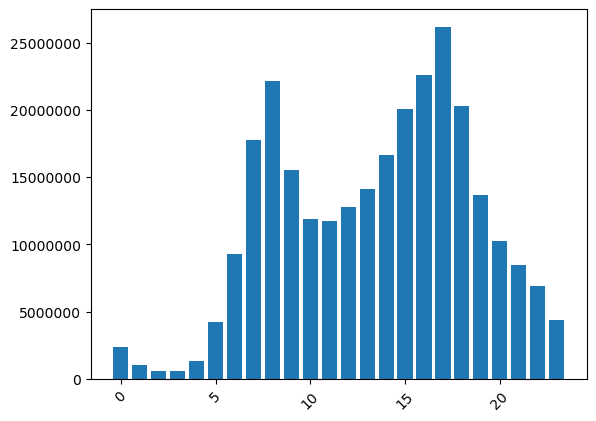

hour of the day: total ridership
0: 2355952.4046
1: 1016291.5595
2: 609685.6535
3: 587057.7875999999
4: 1326038.5767
5: 4238283.6273
6: 9272181.559999999
7: 17772294.2271
8: 22146316.1456
9: 15563042.169400001
10: 11917519.1109
11: 11710357.1202
12: 12744275.600900002
13: 14148107.2139
14: 16629629.3381
15: 20079622.951
16: 22617136.205799997
17: 26183460.9067
18: 20315118.98
19: 13689476.8277
20: 10242757.240699999
21: 8457048.3487
22: 6893768.514900001
23: 4379941.036


In [6]:
# origin hour of day
hour_of_day = origin['hour_of_day'].unique()
total_ridership_per_hour_of_day = [origin[origin['hour_of_day'] == i]['sum_estimated_average_ridership'].sum() for i in hour_of_day]
plt.bar(hour_of_day, total_ridership_per_hour_of_day)
plt.tick_params(axis='x', labelrotation=45)
plt.ticklabel_format(style='plain')
plt.show()
print('hour of the day: total ridership')
for i in range(len(hour_of_day)):
    print(f'{hour_of_day[i]}: {total_ridership_per_hour_of_day[i]}')

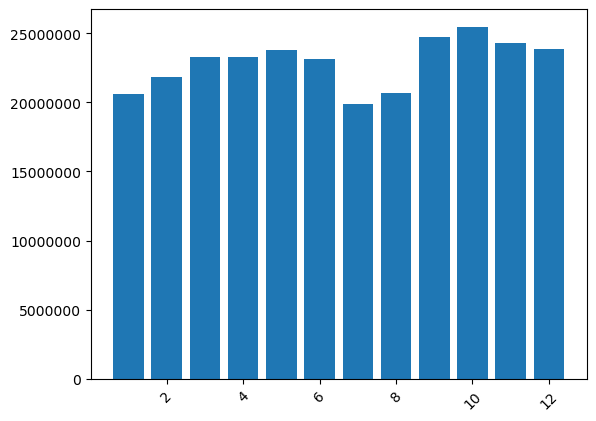

month of the year: total ridership
1: 20640117.3487
2: 21858037.6738
3: 23312621.7179
4: 23260391.0992
5: 23755413.8423
6: 23114608.935900003
7: 19875121.7932
8: 20686265.5928
9: 24742325.3384
10: 25464468.3014
11: 24320913.061899997
12: 23865078.4013


In [7]:
# origin month of year
month = origin['month'].unique()
total_ridership_per_month = [origin[origin['month'] == i]['sum_estimated_average_ridership'].sum() for i in month]
plt.bar(month, total_ridership_per_month)
plt.tick_params(axis='x', labelrotation=45)
plt.ticklabel_format(style='plain')
plt.show()
print('month of the year: total ridership')
for i in range(len(month)):
    print(f'{month[i]}: {total_ridership_per_month[i]}')

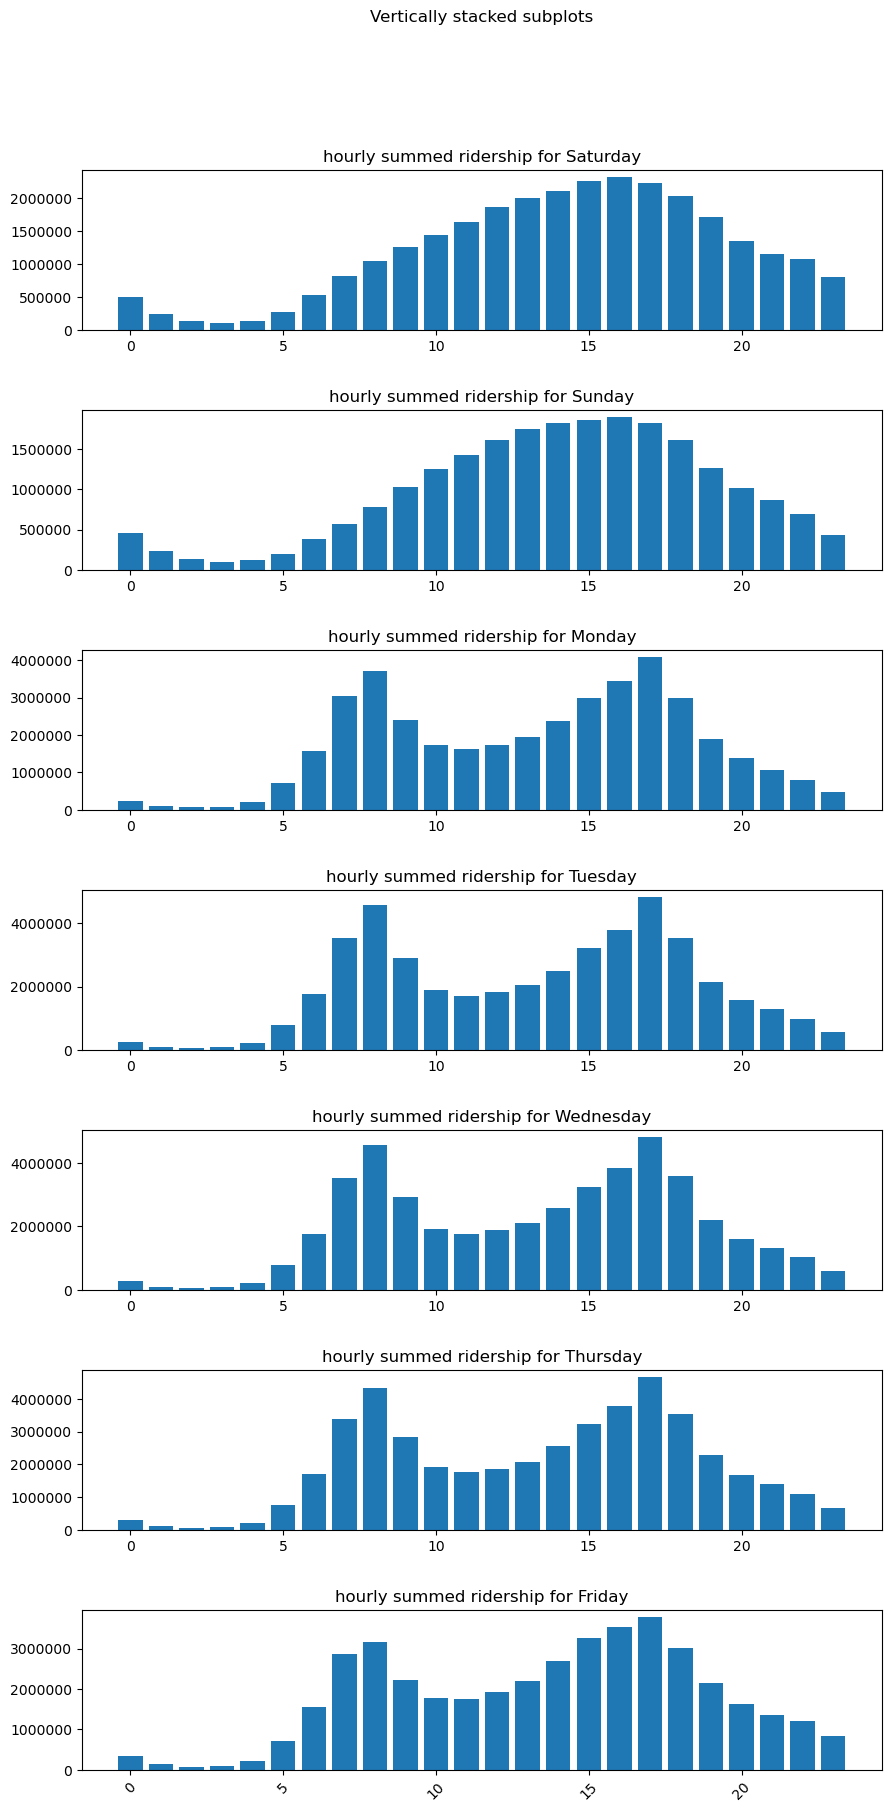

In [8]:
#origin hour of the day by day of the week
day_of_week = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']



fig, axs = plt.subplots(7, figsize = (10,20))
fig.suptitle('Vertically stacked subplots')
fig.subplots_adjust(wspace=0.5, hspace=0.5, top=0.9, bottom=0.1, left=0.1, right=0.9)


for i in range(7):
    daily_dataset = origin[origin['day_of_week'] == day_of_week[i]]
    

    hour_of_day = daily_dataset['hour_of_day'].unique()
    total_ridership_per_hour_of_day = [daily_dataset[daily_dataset['hour_of_day'] == j]['sum_estimated_average_ridership'].sum() for j in hour_of_day]
    axs[i].bar(hour_of_day, total_ridership_per_hour_of_day)
    axs[i].set_title(f'hourly summed ridership for {day_of_week[i]}')
    axs[i].ticklabel_format(style='plain')


plt.tick_params(axis='x', labelrotation=45)

plt.show()


In [9]:
origin.head()

,month,day_of_week,hour_of_day,origin_station_complex_id,origin_station_complex_name,origin_latitude,origin_longitude,origin_point,sum_estimated_average_ridership
0,1,Friday,0,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),35.7473
1,1,Friday,1,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),11.4975
2,1,Friday,2,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),10.9980
3,1,Friday,3,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),14.7534
4,1,Friday,4,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),52.0023


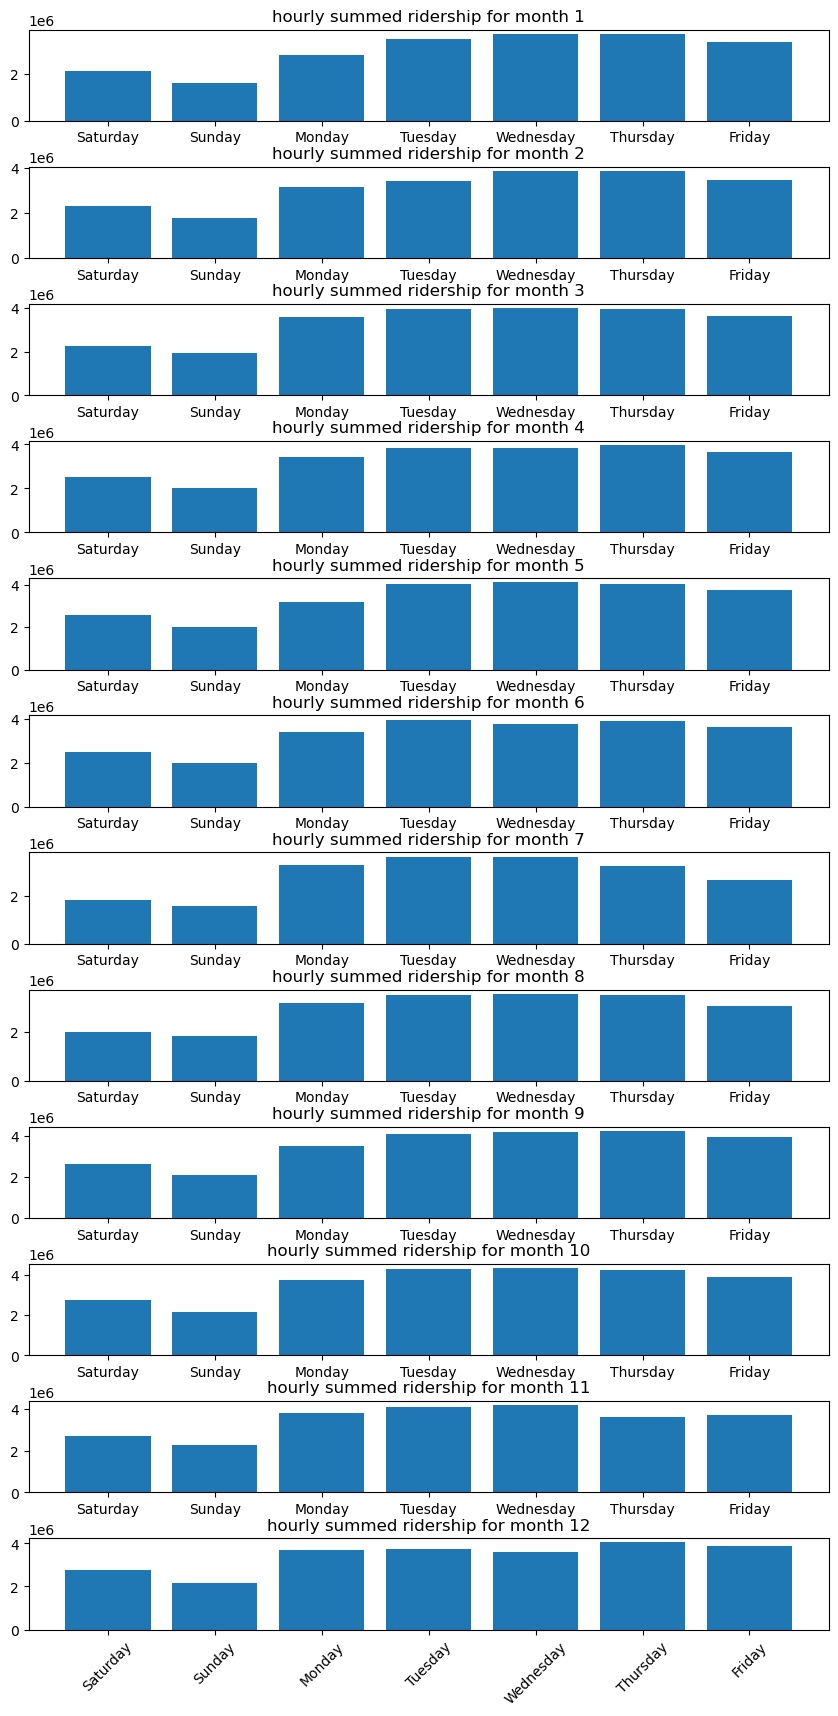

In [10]:
#origin day of the week by the month
day_of_week = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']



fig, axs = plt.subplots(12, figsize = (10,20))
# fig.suptitle('Vertically stacked subplots')
fig.subplots_adjust(wspace=0.5, hspace=0.5, top=0.9, bottom=0.1, left=0.1, right=0.9)


for i in range(12):
    daily_dataset = origin[origin['month'] == i+1]
    

    total_ridership_per_day_of_week = [daily_dataset[daily_dataset['day_of_week'] == j]['sum_estimated_average_ridership'].sum() for j in day_of_week]
    axs[i].bar(day_of_week, total_ridership_per_day_of_week)
    axs[i].set_title(f'hourly summed ridership for month {i+1}')


plt.tick_params(axis='x', labelrotation=45)

plt.show()

In [11]:
# Create a column 'Season' based on Month
origin['season'] = np.select(
    [
        (origin['month'] >= 3) & (origin['month'] <= 5),          # Condition 1
        (origin['month'] >= 6) & (origin['month'] <= 8),  # Condition 2
        (origin['month'] >= 9) & (origin['month'] <= 11),
        (origin['month'] == 12) | (origin['month'] <= 2)
    ],
    [
        'spring',  # Value if Condition 1 is True
        'summer',    # Value if Condition 2 is True
        'fall',
        'winter'
    ],
    default='Unknown'
)

origin.head()

,month,day_of_week,hour_of_day,origin_station_complex_id,origin_station_complex_name,origin_latitude,origin_longitude,origin_point,sum_estimated_average_ridership,season
0,1,Friday,0,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),35.7473,winter
1,1,Friday,1,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),11.4975,winter
2,1,Friday,2,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),10.9980,winter
3,1,Friday,3,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),14.7534,winter
4,1,Friday,4,1,"Astoria-Ditmars Blvd (N,W)",40.775036,-73.912034,POINT (-73.912034 40.775036),52.0023,winter


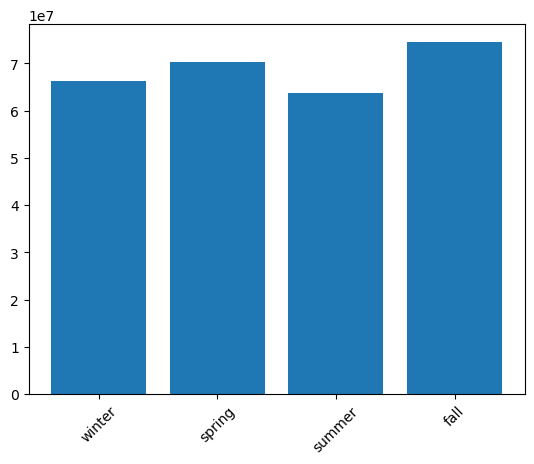

season of the year: total ridership
winter: 66363233.42380001
spring: 70328426.6594
summer: 63675996.321899995
fall: 74527706.7017


In [12]:
# origin season
season = ['winter', 'spring', 'summer', 'fall']

season = origin['season'].unique()
total_ridership_per_season = [origin[origin['season'] == i]['sum_estimated_average_ridership'].sum() for i in season]
plt.bar(season, total_ridership_per_season)
plt.tick_params(axis='x', labelrotation=45)
plt.show()
print('season of the year: total ridership')
for i in range(len(season)):
    print(f'{season[i]}: {total_ridership_per_season[i]}')

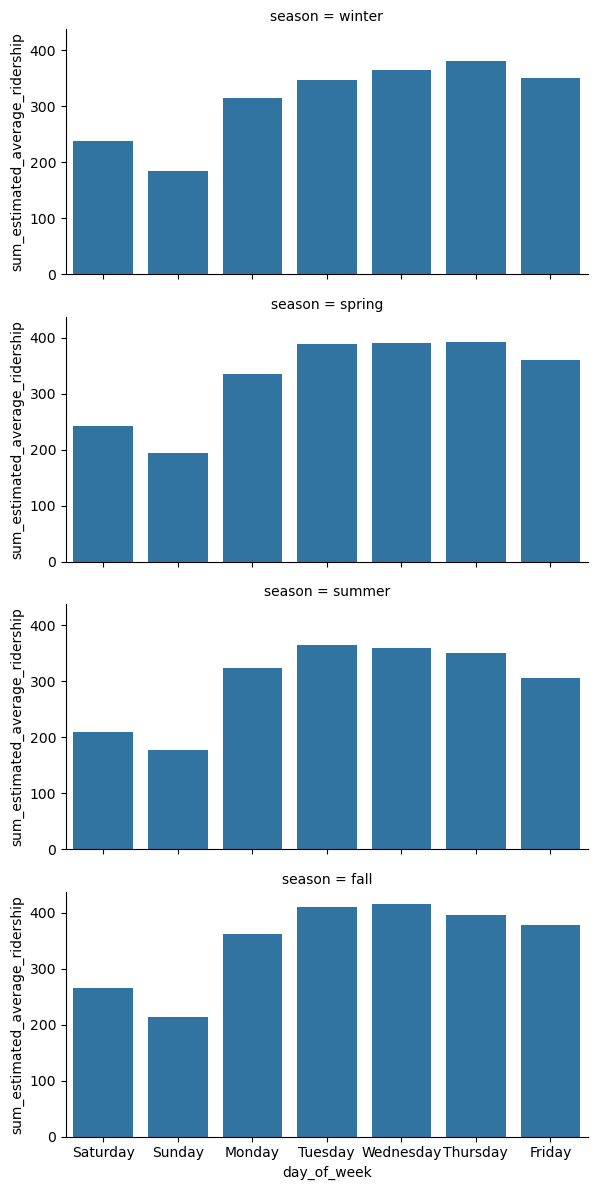

In [13]:
#origin day of the week by the season
season = ['winter', 'spring', 'summer', 'fall']
day_of_week = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']


# Create a faceted bar chart
g = sns.catplot(
    data=origin,
    x='day_of_week',       # X-axis variable
    y='sum_estimated_average_ridership',          # Y-axis variable
    row='season',        # Facet by 'group' (like facet_wrap in R)
    row_order= season,  # Reorder facets
    order= day_of_week,        # Reorder x-axis
    kind='bar',         # Bar chart
    errorbar=None,
    height=3,           # Height of each facet
    aspect=2            # Aspect ratio
)

# Improve layout
#g.set_axis_labels("season", "sum_estimated_average_ridership")
#plt.tight_layout()

plt.show()

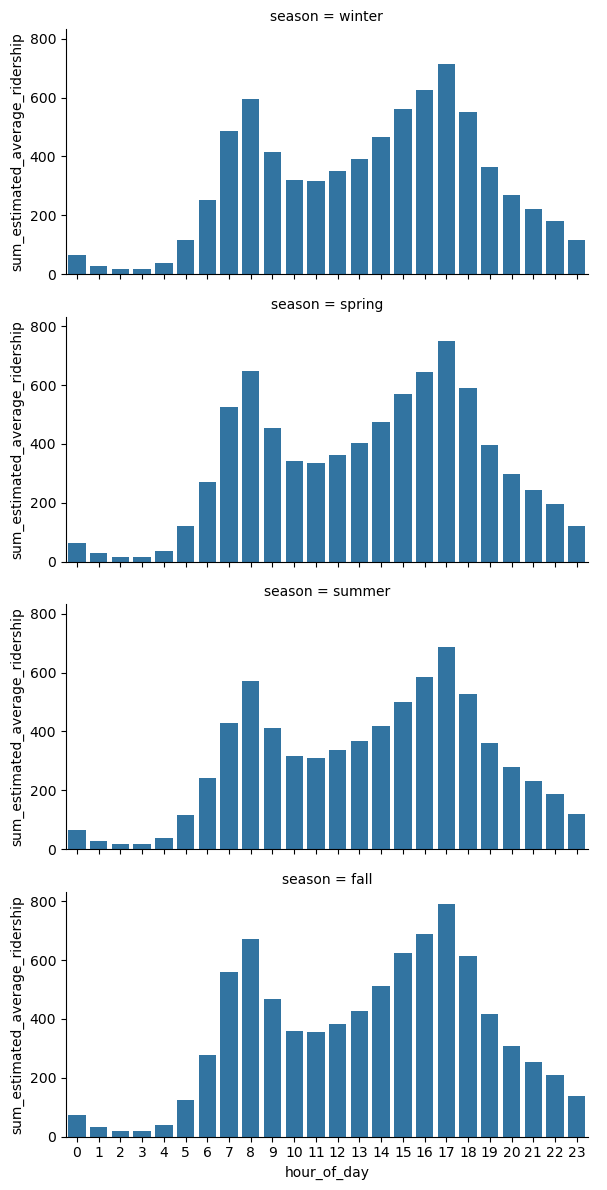

In [14]:
#origin hourly ridership by the season
season = ['winter', 'spring', 'summer', 'fall']


# Create a faceted bar chart
g = sns.catplot(
    data=origin,
    x='hour_of_day',       # X-axis variable
    y='sum_estimated_average_ridership',          # Y-axis variable
    row='season',        # Facet by 'group' (like facet_wrap in R)
    row_order= season,  # Reorder facets
    kind='bar',         # Bar chart
    errorbar=None,
    height=3,           # Height of each facet
    aspect=2            # Aspect ratio
)

plt.show()

In [15]:
# Bar graph of distribution of ridership for all destinations from a given origin point, or vice versa
display(od_flows.head())

,origin_station_complex_name,destination_station_complex_name,origin_station_complex_id,destination_station_complex_id,sum_estimated_average_ridership,geometry,distance_meters,distance_km,log_ridership,riders_per_km,origin_point_wkt,destination_point_wkt
0,Beach 44 St (A),Grand St (L),206,123,30.2032,"LINESTRING (-73.77601 40.59294, -73.94067 40.7...",19191.098843,19.191099,3.440521,1.573813,POINT (-73.776013 40.592943),POINT (-73.94067 40.711926)
1,57 St (F),"Astoria Blvd (N,W)",224,2,595.8536,"LINESTRING (-73.97745 40.76397, -73.91784 40.7...",5079.298729,5.079299,6.391672,117.310210,POINT (-73.97745 40.763972),POINT (-73.917843 40.770258)
2,Rector St (1),Buhre Av (6),329,361,8.8919,"LINESTRING (-74.01378 40.70751, -73.83257 40.8...",21749.099473,21.749099,2.291716,0.408840,POINT (-74.013783 40.707513),POINT (-73.832569 40.84681)
3,"30 Av (N,W)","Simpson St (2,5)",3,430,222.4353,"LINESTRING (-73.92148 40.76678, -73.89306 40.8...",6797.412960,6.797413,5.409122,32.723523,POINT (-73.921479 40.766779),POINT (-73.893064 40.824073)
4,"Northern Blvd (M,R)",2 Av (F),269,232,1036.2171,"LINESTRING (-73.90601 40.75288, -73.98994 40.7...",7806.638810,7.806639,6.944297,132.735371,POINT (-73.906006 40.752885),POINT (-73.989938 40.723402)


## Maps

### Map of Origin/Destination Routes Weighted by Ridership

## Some other stats

### Relating to station ridership over the full year and its ridership
note:  need to multiply by 4 because months are 4 weeks long to actually account for yearly ridership. this is just an easy way of comparing stations

In [68]:
summed_origin_df = origin.groupby(by=["origin_station_complex_name"])['sum_estimated_average_ridership'].sum().sort_values()*4

In [69]:
summed_origin_df

origin_station_complex_name
Broad Channel (A,S)                                 5.703175e+04
Beach 105 St (A,S)                                  6.553987e+04
Beach 98 St (A,S)                                   9.271330e+04
Beach 44 St (A)                                     1.398801e+05
Beach 36 St (A)                                     1.496822e+05
                                                        ...     
Fulton St (A,C,J,Z,2,3,4,5)                         1.757868e+07
14 St-Union Sq (L,N,Q,R,W,4,5,6)                    2.090185e+07
34 St-Herald Sq (B,D,F,M,N,Q,R,W)                   2.282079e+07
Grand Central-42 St (S,4,5,6,7)                     3.093237e+07
Times Sq-42 St (N,Q,R,W,S,1,2,3,7)/42 St (A,C,E)    4.183139e+07
Name: sum_estimated_average_ridership, Length: 424, dtype: float64

In [70]:
for name, value in summed_origin_df.items():
    print(f'station name: {name}, number of riders: {value}')

station name: Broad Channel (A,S), number of riders: 57031.7516
station name: Beach 105 St (A,S), number of riders: 65539.8712
station name: Beach 98 St (A,S), number of riders: 92713.2952
station name: Beach 44 St (A), number of riders: 139880.0696
station name: Beach 36 St (A), number of riders: 149682.1716
station name: Rockaway Park-Beach 116 St (A,S), number of riders: 155250.9128
station name: Aqueduct-N Conduit Av (A), number of riders: 158711.182
station name: Aqueduct Racetrack (A), number of riders: 161945.308
station name: Beach 90 St (A,S), number of riders: 167986.6044
station name: Bay Pkwy (F), number of riders: 235886.6512
station name: E 143 St-St Mary's St (6), number of riders: 245006.5492
station name: Cypress Hills (J), number of riders: 253168.7204
station name: Beach 25 St (A), number of riders: 284013.104
station name: Neptune Av (F), number of riders: 294529.1688
station name: Beach 60 St (A), number of riders: 309175.4704
station name: Avenue I (F), number of 

In [71]:
print(f'mean: \t\t\t{summed_origin_df.mean():.2f}')
print(f'median: \t\t{summed_origin_df.iloc[int(summed_origin_df.size/2)]:.2f}')
print(f'standard deviation:\t{summed_origin_df.std():.2f}')

mean: 			2593352.48
median: 		1410797.02
standard deviation:	3789109.60


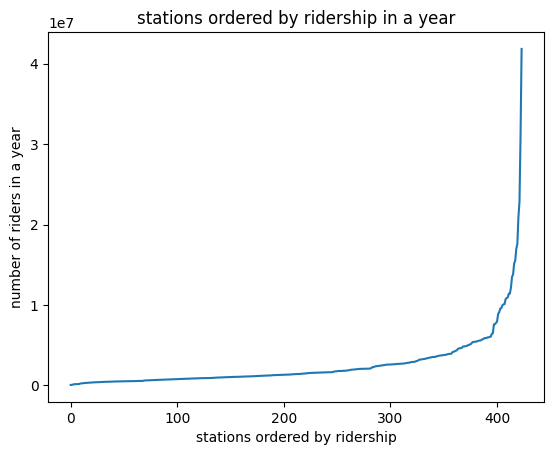

In [74]:
x_axis_data = [i for i in range(summed_origin_df.size)]
plt.plot(x_axis_data, summed_origin_df)
plt.title("stations ordered by ridership in a year")
plt.ylabel("number of riders in a year")
plt.xlabel("stations ordered by ridership")
plt.show()